In [1]:
import numpy as np
import os
dataset_path = "/kaggle/input/garbage-dataset/garbage_classification"
classes = os.listdir(dataset_path)
print (f"Classes found: {classes}")
image_paths, labels = [], []
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(label)

Classes found: ['metal', 'Plastic-bag', 'white-glass', 'biological', 'paper', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'Bottle']


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2
import tensorflow as tf
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
from skimage import feature
import numpy as np
import warnings
warnings.filterwarnings('ignore')

2026-01-19 10:43:29.418654: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768819409.441018     118 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768819409.447668     118 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
import cv2
import numpy as np
from skimage import feature
import os
# --- CẤU HÌNH ĐẶC TRƯNG ---
# LBP
LBP_RADIUS = 3
LBP_N_POINTS = LBP_RADIUS * 8 

# HIST
HIST_BINS = 8 
HIST_RANGES_HSV = [0, 180, 0, 256, 0, 256] 

# HOG
HOG_ORIENTATIONS = 9
HOG_PPC = (8, 8) # Pixels per cell
HOG_CPB = (2, 2) # Cells per block
# Resize ảnh về kích thước cố định, ví dụ 128x128
RESIZE_SIZE = (128, 128) 

# HÀM 1: TÍNH ĐẶC TRƯNG HOG (Hình dạng)

def get_hog_features(img_gray):
    """Tính HOG features từ ảnh xám (đã resize)."""
    hog_feat = feature.hog(
        img_gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PPC,
        cells_per_block=HOG_CPB,
        transform_sqrt=True, # Lượng tử hóa căn bậc hai giúp cải thiện hiệu suất
        feature_vector=True
    )
    return hog_feat

# HÀM 2: TÍNH ĐẶC TRƯNG LBP (Kết cấu)

def get_lbp_features(img_gray):
    """Tính LBP Histogram từ ảnh xám (đã resize)."""
    lbp_image = feature.local_binary_pattern(
        img_gray, 
        LBP_N_POINTS, 
        LBP_RADIUS, 
        method="uniform"
    )
    (hist, _) = np.histogram(
        lbp_image.ravel(),
        bins=np.arange(0, LBP_N_POINTS + 3),
        range=(0, LBP_N_POINTS + 2)
    )
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# HÀM 3: TÍNH ĐẶC TRƯNG HIST (Màu sắc)

def get_hist_features(img_bgr):
    """Tính 3D HSV Histogram từ ảnh màu."""
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist(
        [img_hsv], 
        [0, 1, 2], 
        None,      
        [HIST_BINS, HIST_BINS, HIST_BINS],
        HIST_RANGES_HSV 
    )
    hist = cv2.normalize(hist, hist).flatten()
    return hist

# HÀM 4: TÍNH ĐẶC TRƯNG KẾT HỢP

def compute_all_combined_features(image_path):
    """
    Tính và nối đặc trưng HOG, LBP, và HIST.
    """
    try:
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            return None
        
        # 1. Resize ảnh
        img_bgr = cv2.resize(img_bgr, RESIZE_SIZE)
        
        # 2. Ảnh xám (cho HOG và LBP)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
        # 3. Tính toán các đặc trưng
        hog_feat = get_hog_features(img_gray)
        lbp_feat = get_lbp_features(img_gray)
        hist_feat = get_hist_features(img_bgr)
        
        # 4. Nối vector đặc trưng
        combined_feat = np.concatenate([hog_feat, lbp_feat, hist_feat])
        
        return combined_feat
    
    except Exception as e:
        print(f"Lỗi xử lý {image_path}: {e}")
        return None

# THỰC HIỆN TÍNH ĐẶC TRƯNG KẾT HỢP

print("\nĐang tính Combined HOG + LBP + HIST features...")
combined_features_list = []
valid_labels = []
valid_image_paths = [] 

# Giả định: image_paths và labels đã được load
# ... (Vòng lặp for img_path, label trong zip(image_paths, labels)):
for idx, (img_path, label) in enumerate(zip(image_paths, labels)):
    if idx % 500 == 0:
        print(f"Đã xử lý {idx}/{len(image_paths)}")
    
    combined_feat = compute_all_combined_features(img_path) 
    
    if combined_feat is not None:
        combined_features_list.append(combined_feat)
        valid_labels.append(label)
        valid_image_paths.append(img_path)

# Chuyển thành numpy array
X = np.array(combined_features_list)
y = np.array(valid_labels)

# Tính tổng chiều (phải chạy HOG trên kích thước 128x128 để biết chính xác)
# Ví dụ: HOG trên 128x128 sẽ là 9 * (128/8) * (128/8) * (2*2) = 9 * 16 * 16 * 4 = 9216
# Nếu dùng tham số trên: Dim = HOG + LBP(26) + HIST(512)
print(f"\nCombined HOG + LBP + HIST features shape: {X.shape}") 
print(f"Labels shape: {y.shape}")


Đang tính Combined HOG + LBP + HIST features...
Đã xử lý 0/15376
Đã xử lý 500/15376
Đã xử lý 1000/15376
Đã xử lý 1500/15376
Đã xử lý 2000/15376
Đã xử lý 2500/15376
Đã xử lý 3000/15376
Đã xử lý 3500/15376
Đã xử lý 4000/15376
Đã xử lý 4500/15376
Đã xử lý 5000/15376
Đã xử lý 5500/15376
Đã xử lý 6000/15376
Đã xử lý 6500/15376
Đã xử lý 7000/15376
Đã xử lý 7500/15376
Đã xử lý 8000/15376
Đã xử lý 8500/15376
Đã xử lý 9000/15376
Đã xử lý 9500/15376
Đã xử lý 10000/15376
Đã xử lý 10500/15376
Đã xử lý 11000/15376
Đã xử lý 11500/15376
Đã xử lý 12000/15376
Đã xử lý 12500/15376
Đã xử lý 13000/15376
Đã xử lý 13500/15376
Đã xử lý 14000/15376
Đã xử lý 14500/15376
Đã xử lý 15000/15376

Combined HOG + LBP + HIST features shape: (15376, 8638)
Labels shape: (15376,)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

TEST_SIZE_RATIO = 0.20  
VALID_SIZE_RATIO = 0.20 
TEMP_SIZE = TEST_SIZE_RATIO + VALID_SIZE_RATIO 

# BƯỚC 1: CHIA TRAIN VÀ TẠM THỜI (TEMP)

X_train_raw, X_temp, y_train, y_temp, paths_train, paths_temp = train_test_split(
    X, 
    y, 
    valid_image_paths, 
    test_size=TEMP_SIZE, 
    random_state=42, 
    stratify=y
)

# BƯỚC 2: CHUẨN HÓA ĐẶC TRƯNG (FEATURE SCALING)

print("BẮT ĐẦU CHUẨN HÓA ĐẶC TRƯNG (StandardScaler)")
scaler = StandardScaler()

# 1. FIT (học tham số mean và std) chỉ trên tập TRAIN
# Đảm bảo KHÔNG CÓ rò rỉ dữ liệu từ Valid/Test vào quá trình huấn luyện
X_train = scaler.fit_transform(X_train_raw)

# 2. TRANSFORM (áp dụng tham số đã học) lên tập Temp
X_temp_scaled = scaler.transform(X_temp)

print(f"Kích thước X_train sau chuẩn hóa: {X_train.shape}")
print(f"Kích thước X_temp sau chuẩn hóa: {X_temp_scaled.shape}")


# BƯỚC 3: CHIA TẬP TẠM THỜI (TEMP) THÀNH VALID VÀ TEST

valid_test_ratio = TEST_SIZE_RATIO / TEMP_SIZE 

X_valid, X_test, y_valid, y_test, paths_valid, paths_test = train_test_split(
    X_temp_scaled, # Sử dụng X_temp đã được chuẩn hóa
    y_temp, 
    paths_temp,
    test_size=valid_test_ratio,
    random_state=42, 
    stratify=y_temp
)

# KIỂM TRA KÍCH THƯỚC CUỐI CÙNG

print("KÍCH THƯỚC CÁC TẬP DỮ LIỆU ĐÃ CHUẨN HÓA:")
print(f"1. Tập Huấn luyện (Train): {X_train.shape[0]} samples")
print(f"2. Tập Thẩm định (Valid): {X_valid.shape[0]} samples")
print(f"3. Tập Kiểm thử (Test): {X_test.shape[0]} samples")
print(f"Feature dimensions: {X_train.shape[1]}")

BẮT ĐẦU CHUẨN HÓA ĐẶC TRƯNG (StandardScaler)
Kích thước X_train sau chuẩn hóa: (9225, 8638)
Kích thước X_temp sau chuẩn hóa: (6151, 8638)
KÍCH THƯỚC CÁC TẬP DỮ LIỆU ĐÃ CHUẨN HÓA:
1. Tập Huấn luyện (Train): 9225 samples
2. Tập Thẩm định (Valid): 3075 samples
3. Tập Kiểm thử (Test): 3076 samples
Feature dimensions: 8638


In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# --- THAM SỐ CỐ ĐỊNH BAN ĐẦU ---
FIXED_C = 1.0
FIXED_GAMMA = 'scale'

# BƯỚC 1: HUẤN LUYỆN SVM VỚI THAM SỐ CỐ ĐỊNH

print(f"HUẤN LUYỆN MÔ HÌNH SVM CƠ SỞ (C={FIXED_C}, Gamma='{FIXED_GAMMA}')")

# Khởi tạo và huấn luyện mô hình trên tập TRAIN
fixed_svm_model = SVC(
    kernel='rbf',       
    C=FIXED_C,              
    gamma=FIXED_GAMMA,      
    random_state=42     
)

fixed_svm_model.fit(X_train, y_train)

print("Huấn luyện hoàn tất.")

HUẤN LUYỆN MÔ HÌNH SVM CƠ SỞ (C=1.0, Gamma='scale')
Huấn luyện hoàn tất.


In [6]:

# BƯỚC 2: ĐÁNH GIÁ VÀ BÁO CÁO TRÊN TẬP VALIDATION

# 1. Dự đoán trên tập Validation
y_pred_valid = fixed_svm_model.predict(X_valid)
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
print(f"ĐỘ CHÍNH XÁC trên tập Thẩm định (Validation): {valid_accuracy:.4f}")

ĐỘ CHÍNH XÁC trên tập Thẩm định (Validation): 0.7314


In [7]:
# 2. Báo cáo Phân loại trên Validation
num_classes = len(classes)
all_labels = list(range(num_classes)) 

print("\nValidation (Classification Report):")
print(classification_report(y_valid, y_pred_valid, target_names=classes, labels=all_labels))
print("-" * 60)


Validation (Classification Report):
              precision    recall  f1-score   support

       metal       0.57      0.48      0.52       155
 Plastic-bag       0.81      0.51      0.62       142
 white-glass       0.57      0.54      0.56       155
  biological       0.80      0.53      0.64       197
       paper       0.73      0.65      0.69       211
     battery       0.62      0.72      0.67       189
       trash       0.88      0.54      0.67       140
   cardboard       0.72      0.37      0.49       178
       shoes       0.64      0.76      0.69       395
     clothes       0.80      0.97      0.88      1065
      Bottle       0.72      0.67      0.69       248

    accuracy                           0.73      3075
   macro avg       0.71      0.61      0.65      3075
weighted avg       0.73      0.73      0.72      3075

------------------------------------------------------------


In [8]:
# BƯỚC 3: ĐÁNH GIÁ VÀ BÁO CÁO TRÊN TẬP TEST (Đánh giá cuối cùng)
# 1. Dự đoán trên tập Test
y_pred_test = fixed_svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"ĐỘ CHÍNH XÁC trên tập Kiểm thử (Test): {test_accuracy:.4f}")

ĐỘ CHÍNH XÁC trên tập Kiểm thử (Test): 0.7259


In [9]:
# 2. Báo cáo Phân loại trên Test
print("\nTest (Classification Report):")
print(classification_report(y_test, y_pred_test, target_names=classes, labels=all_labels))
print("="*60)


Test (Classification Report):
              precision    recall  f1-score   support

       metal       0.54      0.39      0.45       154
 Plastic-bag       0.83      0.46      0.59       142
 white-glass       0.58      0.52      0.55       155
  biological       0.81      0.57      0.67       197
       paper       0.73      0.65      0.69       212
     battery       0.61      0.76      0.68       189
       trash       0.77      0.50      0.60       139
   cardboard       0.77      0.33      0.46       178
       shoes       0.65      0.74      0.69       396
     clothes       0.79      0.97      0.87      1065
      Bottle       0.71      0.71      0.71       249

    accuracy                           0.73      3076
   macro avg       0.71      0.60      0.63      3076
weighted avg       0.73      0.73      0.71      3076



MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST


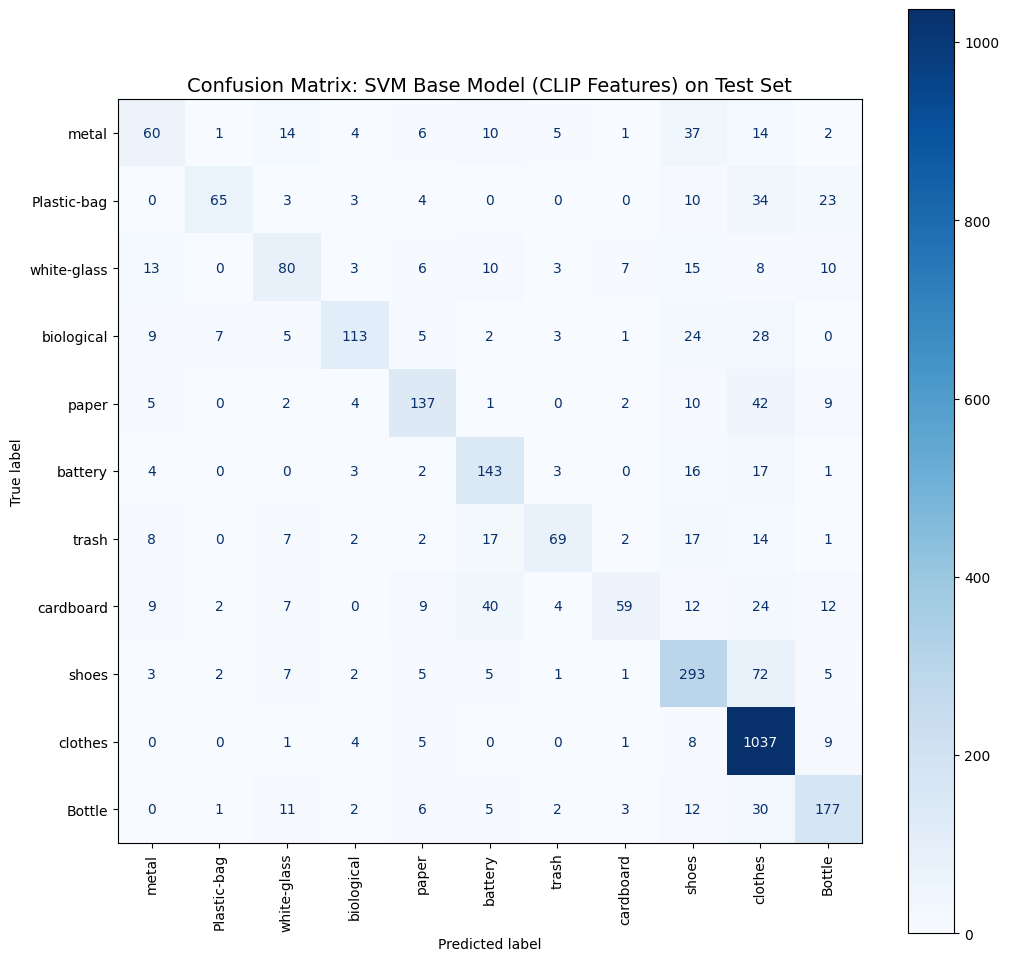


Ma trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: confusion_matrix_svm_baseline_test.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tính toán Ma trận nhầm lẫn

num_classes = len(classes)

all_labels = list(range(num_classes)) 

cm = confusion_matrix(
    y_test, 
    y_pred_test, 
    labels=all_labels # Đảm bảo ma trận có kích thước 11x11
)

# 2. Trực quan hóa Ma trận nhầm lẫn
print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST")

# Khởi tạo figure
fig, ax = plt.subplots(figsize=(12, 12)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Hiển thị ma trận
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix: SVM Base Model (CLIP Features) on Test Set', fontsize=14)


# 3. Lưu hình ảnh
file_name = "confusion_matrix_svm_baseline_test.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\nMa trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: {file_name}")

HIỂN THỊ 2 ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN TRÊN TẬP TEST (Tổng: 2233 ảnh)


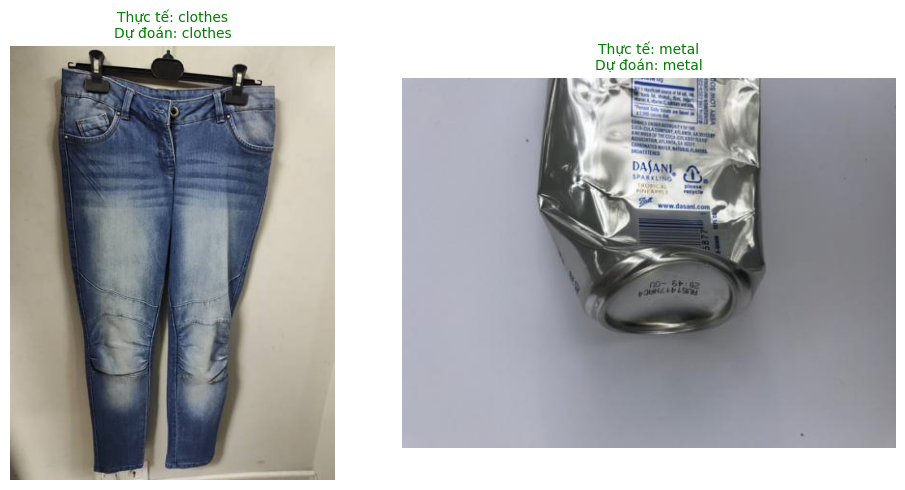

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

correctly_classified_mask = (y_test == y_pred_test)
indices_in_test_set = np.where(correctly_classified_mask)[0]
num_correctly_classified = len(indices_in_test_set)

print(f"HIỂN THỊ 2 ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN TRÊN TẬP TEST (Tổng: {num_correctly_classified} ảnh)")
# Chọn số lượng ảnh muốn hiển thị
num_to_display = min(2, num_correctly_classified) 

if num_correctly_classified > 0:
    # Lấy ngẫu nhiên 'num_to_display' chỉ mục
    random_correct_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False 
    )
    
    # Khởi tạo figure chỉ khi có mẫu để hiển thị
    fig, axes = plt.subplots(1, num_to_display, figsize=(10, 5))
    
    # Xử lý trường hợp chỉ hiển thị 1 ảnh
    if num_to_display == 1:
        axes = [axes] 

    for i in range(num_to_display):
        # Lấy chỉ mục đã chọn ngẫu nhiên
        test_idx = random_correct_indices[i] 
        
        # Lấy thông tin nhãn
        true_label = y_test[test_idx]
        pred_label = y_pred_test[test_idx]
        true_class_name = classes[true_label]
        predicted_class_name = classes[pred_label]
        
        # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
        image_path = paths_test[test_idx] 
        image = cv2.imread(image_path)
        
        if image is None:
            image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
            title_color = 'gray'
        else:
            # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Màu xanh lá cho dự đoán đúng
            title_color = 'green' 
        
        # Hiển thị ảnh
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                          color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print(" Không có bất kỳ mẫu nào được phân loại đúng trong tập Test. Không thể hiển thị hình ảnh.")

HIỂN THỊ 2 ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN TRÊN TẬP TEST (Tổng: 843 ảnh)


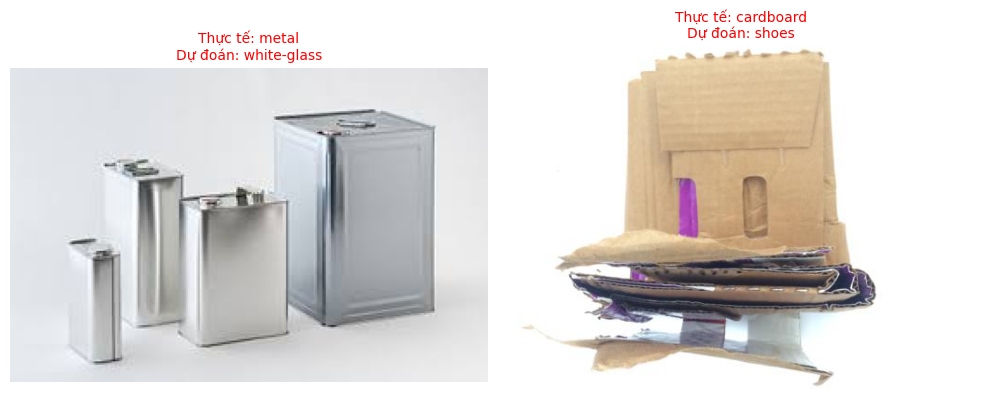

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

# 1. Tìm các chỉ mục (indices) nơi dự đoán SAI
misclassified_mask = (y_test != y_pred_test)
indices_in_test_set = np.where(misclassified_mask)[0]
num_misclassified = len(indices_in_test_set)

print("="*60)
print(f"HIỂN THỊ 2 ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN TRÊN TẬP TEST (Tổng: {num_misclassified} ảnh)")
print("="*60)

# Chọn số lượng ảnh muốn hiển thị
num_to_display = min(2, num_misclassified) 


if num_misclassified > 0:
    # Lấy ngẫu nhiên 'num_to_display' chỉ mục
    random_misclassified_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False 
    )
    
    # Khởi tạo figure chỉ khi có mẫu để hiển thị
    fig, axes = plt.subplots(1, num_to_display, figsize=(10, 5))
    
    # Xử lý trường hợp chỉ hiển thị 1 ảnh
    if num_to_display == 1:
        axes = [axes] 

    for i in range(num_to_display):
        # Lấy chỉ mục đã chọn ngẫu nhiên
        test_idx = random_misclassified_indices[i] 
        
        # Lấy thông tin nhãn
        true_label = y_test[test_idx]
        pred_label = y_pred_test[test_idx]
        true_class_name = classes[true_label]
        predicted_class_name = classes[pred_label]
        
        # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
        image_path = paths_test[test_idx] 
        image = cv2.imread(image_path)
        
        if image is None:
            image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
            title_color = 'gray'
        else:
            # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Màu đỏ cho dự đoán sai
            title_color = 'red' 
        
        # Hiển thị ảnh
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                          color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Không có mẫu nào bị phân loại sai trong tập Test. (Chúc mừng! Hoặc kiểm tra lại dữ liệu). Không thể hiển thị hình ảnh.")

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import time

# BƯỚC 1: XÁC ĐỊNH LƯỚI THAM SỐ VÀ KHỞI TẠO GRID SEARCH

# Phạm vi các giá trị C và gamma cần thử nghiệm
param_grid = {
    'C': [0.1, 1, 10,100], # Thử nghiệm các giá trị C khác nhau
    'gamma': ['scale', 0.01, 0.1], # Thử nghiệm các giá trị gamma khác nhau
    'kernel': ['rbf'] 
}

base_svm = SVC(random_state=42)

print("BẮT ĐẦU TỐI ƯU THAM SỐ SVM (GRID SEARCH CV) TRÊN TẬP TRAIN")
start_time = time.time()

# Grid Search sẽ tìm kiếm tham số tốt nhất qua 3-fold Cross-Validation trên X_train
grid_search = GridSearchCV(
    estimator=base_svm, 
    param_grid=param_grid, 
    cv=3, 
    verbose=2, 
    n_jobs=-1, # Sử dụng tất cả các lõi CPU
    scoring='accuracy' 
)

# Chạy tìm kiếm
grid_search.fit(X_train, y_train)

end_time = time.time()
print(f"\nThời gian chạy Grid Search: {end_time - start_time:.2f} giây")
print("="*60)

# BƯỚC 2: ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT TRÊN TẬP TEST

# Lấy mô hình SVM tốt nhất đã được tối ưu
best_svm_model = grid_search.best_estimator_

print(f"Tham số TỐT NHẤT tìm được: {grid_search.best_params_}")
print(f"Độ chính xác TỐT NHẤT (Cross-Validation trên Train): {grid_search.best_score_:.4f}")
print("-" * 60)

# Dự đoán trên tập Test BẰNG MÔ HÌNH TỐT NHẤT
y_pred_final = best_svm_model.predict(X_test)

# 1. Độ chính xác cuối cùng
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Độ chính xác CUỐI CÙNG trên tập TEST: {final_accuracy:.4f}")

# 2. Báo cáo Phân loại cuối cùng
num_classes = len(classes)
all_labels = list(range(num_classes)) 

print("\nBáo cáo Phân loại CUỐI CÙNG (Classification Report trên Test):")
print(classification_report(y_test, y_pred_final, target_names=classes, labels=all_labels))

BẮT ĐẦU TỐI ƯU THAM SỐ SVM (GRID SEARCH CV) TRÊN TẬP TRAIN
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=14.1min
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=19.9min
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=13.6min
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=20.2min
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=19.5min
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=16.6min
[CV] END ........................C=10, gamma=0.1, kernel=rbf; total time=20.1min
[CV] END .....................C=100, gamma=scale, kernel=rbf; total time=15.2min
[CV] END ......................C=100, gamma=0.01, kernel=rbf; total time=21.8min
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=13.6min
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total ti

MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐI ƯU TRÊN TẬP TEST


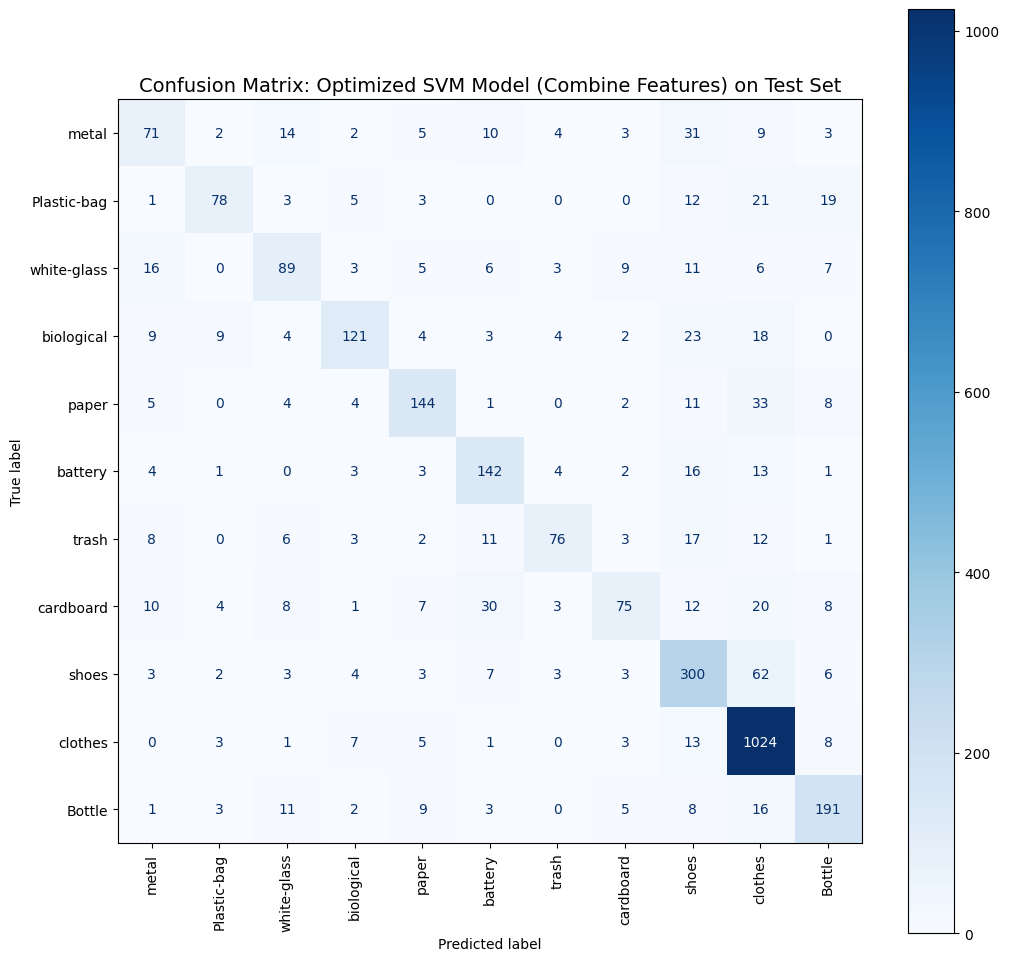


Ma trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: confusion_matrix_svm_optimized_combine_test.png


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tính toán Ma trận nhầm lẫn
num_classes = len(classes)
all_labels = list(range(num_classes)) 

cm = confusion_matrix(
    y_test, 
    y_pred_final, 
    labels=all_labels # Đảm bảo ma trận có kích thước đầy đủ
)

# 2. Trực quan hóa Ma trận nhầm lẫn
print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐI ƯU TRÊN TẬP TEST")

# Khởi tạo figure
fig, ax = plt.subplots(figsize=(12, 12)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes) 

# Hiển thị ma trận
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix: Optimized SVM Model (Combine Features) on Test Set', fontsize=14)

# 3. Lưu hình ảnh
file_name = "confusion_matrix_svm_optimized_combine_test.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\nMa trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: {file_name}")

In [15]:
import joblib
import os 
import time

timestamp = time.strftime("%Y%m%d_%H%M%S")
file_name = f"best_svm_lbp_model_{timestamp}.joblib"

# BƯỚC 1: LƯU MÔ HÌNH

print(f"BẮT ĐẦU LƯU MÔ HÌNH SVM TỐT NHẤT")

try:
    # Lưu mô hình (và các tham số đã được tối ưu) vào file
    joblib.dump(best_svm_model, file_name)
    
    print(f"Mô hình đã được lưu thành công tại: {os.path.abspath(file_name)}")
    print(f"Tham số: {best_svm_model.get_params()}")
except Exception as e:
    print(f"Lỗi khi lưu mô hình: {e}")

print("="*60)

BẮT ĐẦU LƯU MÔ HÌNH SVM TỐT NHẤT
Mô hình đã được lưu thành công tại: /kaggle/working/best_svm_lbp_model_20260119_140758.joblib
Tham số: {'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [16]:
# CHẠY ĐOẠN CODE NÀY TRONG NOTEBOOK/COLAB CỦA BẠN SAU KHI TÍNH SCALER
import joblib
# Giả sử 'scaler' là đối tượng StandardScaler đã fit trên X_train
joblib.dump(scaler, 'scaler_combined_features.joblib')

['scaler_combined_features.joblib']